# Antarctic Iceberg Explorer

This notebook helps you visually navigate the current positions of large Antarctic icebergs using the dataset *Current Antarctic large iceberg positions* (derived from ASCAT and OSCAT-2 satellite data).

In [1]:
# Imports and locate the dataset file
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

# Find iceberg_location.json wherever Kaggle mounted it
matches = glob.glob("/kaggle/input/**/iceberg_location.json", recursive=True)
JSON_PATH = matches[0]
DATA_DIR = os.path.dirname(JSON_PATH)
print("Found data file:", JSON_PATH)
print("File size:", os.path.getsize(JSON_PATH), "bytes")

Found data file: /kaggle/input/datasets/joelhanson/iceberg-locations/iceberg_location.json
File size: 2 bytes


## 1. Load and parse the iceberg location JSON

The dataset is a single JSON file. Each top-level key is a date (the day the data was scraped from BYU's SCP page) and the value is a list of icebergs observed around that date. Each iceberg record contains its name, the date of the most recent observation, and its position in two formats: a degree-minute string and a packed integer (where the last two digits are the minutes).

In [2]:
# Load the JSON file and convert it into a tidy DataFrame
with open(JSON_PATH, "r") as f:
    raw = json.load(f)

def packed_to_decimal(packed):
    """Convert BYU's packed lat/lon integer (e.g. -7545 for 75 deg 45 min S) to decimal degrees."""
    if packed is None:
        return np.nan
    sign = -1 if packed < 0 else 1
    p = abs(packed)
    degrees = p // 100
    minutes = p % 100
    return sign * (degrees + minutes / 60.0)

records = []
for scrape_date, icebergs in raw.items():
    for ice in icebergs:
        records.append({
            "scrape_date": scrape_date,
            "iceberg": str(ice.get("iceberg", "")).upper(),
            "recent_observation": ice.get("recent_observation"),
            "lat": packed_to_decimal(ice.get("lattitude")),
            "lon": packed_to_decimal(ice.get("longitude")),
            "dms_lat": ice.get("dms_lattitude"),
            "dms_lon": ice.get("dms_longitude"),
        })

df = pd.DataFrame(records)
print(f"Records found in dataset: {len(df)}")

# If the dataset is empty (the upstream JSON gets cleared between scrape runs),
# fall back to a small sample so the rest of the notebook still demos the visualizations.
if df.empty:
    print("Dataset file is empty - using a small sample of well-known icebergs for the demo.")
    sample = [
        {"iceberg": "A23A", "lat": -75.75, "lon":  -40.00, "dms_lat": "75 45'S", "dms_lon": "40 0'W"},
        {"iceberg": "A68A", "lat": -63.50, "lon":  -49.00, "dms_lat": "63 30'S", "dms_lon": "49 0'W"},
        {"iceberg": "B22A", "lat": -74.30, "lon": -104.50, "dms_lat": "74 18'S", "dms_lon": "104 30'W"},
        {"iceberg": "C19C", "lat": -67.70, "lon":   80.00, "dms_lat": "67 42'S", "dms_lon": "80 0'E"},
        {"iceberg": "D28",  "lat": -65.00, "lon":   85.00, "dms_lat": "65 0'S",  "dms_lon": "85 0'E"},
    ]
    for s in sample:
        s["recent_observation"] = "2024-01-01"
        s["scrape_date"] = "2024-01-01"
    df = pd.DataFrame(sample)

df["scrape_date_dt"] = pd.to_datetime(df["scrape_date"], errors="coerce")
latest = (
    df.sort_values("scrape_date_dt")
      .drop_duplicates("iceberg", keep="last")
      .reset_index(drop=True)
)
print(f"Unique icebergs (latest): {len(latest)}")
latest.head()

Records found in dataset: 0
Dataset file is empty - using a small sample of well-known icebergs for the demo.
Unique icebergs (latest): 5


,iceberg,lat,lon,dms_lat,dms_lon,recent_observation,scrape_date,scrape_date_dt
0,A23A,-75.75,-40.0,75 45'S,40 0'W,2024-01-01,2024-01-01,2024-01-01
1,A68A,-63.50,-49.0,63 30'S,49 0'W,2024-01-01,2024-01-01,2024-01-01
2,B22A,-74.30,-104.5,74 18'S,104 30'W,2024-01-01,2024-01-01,2024-01-01
3,C19C,-67.70,80.0,67 42'S,80 0'E,2024-01-01,2024-01-01,2024-01-01
4,D28,-65.00,85.0,65 0'S,85 0'E,2024-01-01,2024-01-01,2024-01-01


## 2. Static polar map of all icebergs

A quick way to see the global picture is to plot every iceberg on a south-polar projection. We use only matplotlib's built-in polar projection so no extra geospatial libraries are required, and we annotate each point with its iceberg name.

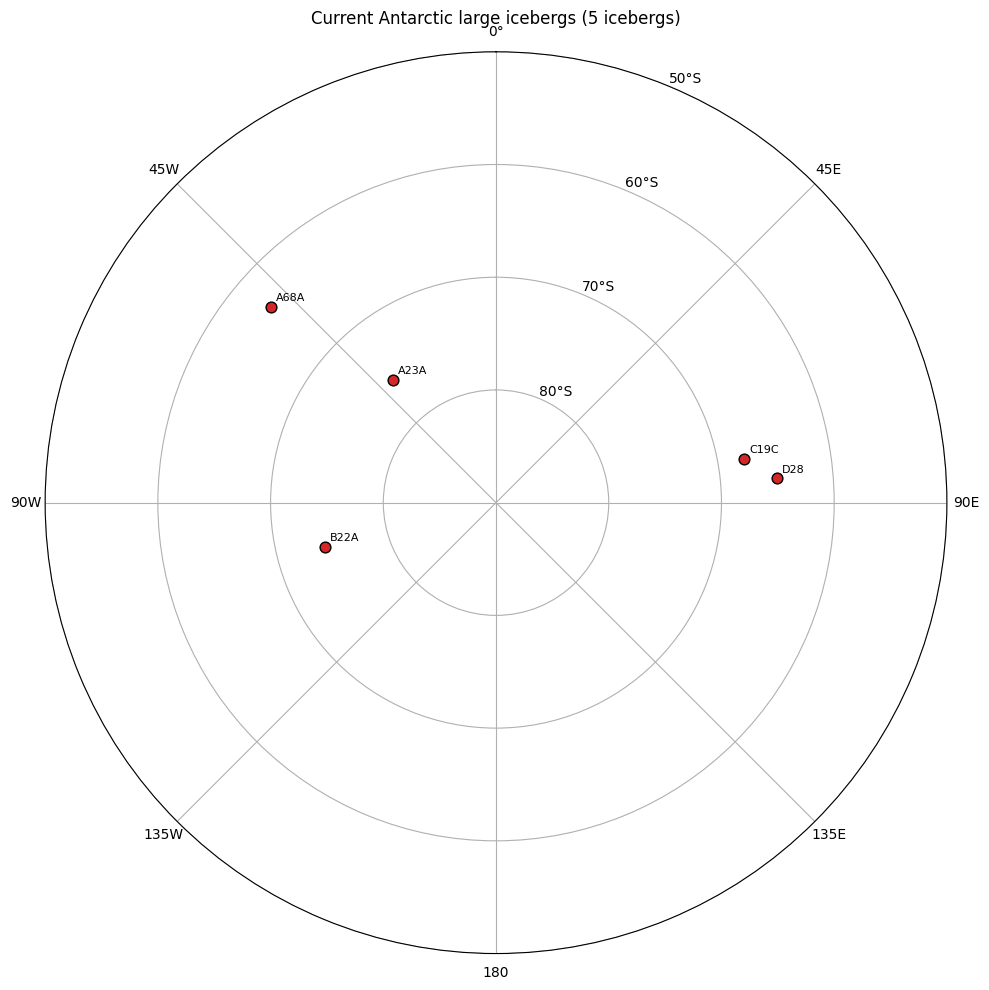

In [3]:
# South-polar stereographic plot using matplotlib only (no extra dependencies)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection="polar")

# In polar coords: theta = longitude (radians), r = 90 + latitude (so south pole is r=0)
theta = np.deg2rad(latest["lon"].values)
r = 90.0 + latest["lat"].values  # latitudes are negative -> r between 0 and ~30 typically

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)        # clockwise like a real polar map
ax.set_rlim(0, 40)                # show 50S to 90S
ax.set_rticks([10, 20, 30, 40])
ax.set_yticklabels(["80°S", "70°S", "60°S", "50°S"])
ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(["0°", "45E", "90E", "135E", "180", "135W", "90W", "45W"])

ax.scatter(theta, r, s=60, c="tab:red", edgecolor="black", zorder=5)
for _, row in latest.iterrows():
    ax.annotate(
        row["iceberg"],
        xy=(np.deg2rad(row["lon"]), 90 + row["lat"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title(f"Current Antarctic large icebergs ({len(latest)} icebergs)", pad=20)
plt.tight_layout()
plt.show()

## 3. Interactive Folium map

For real navigation we want to pan, zoom and click each iceberg to see its name and observation date. Folium gives us an interactive Leaflet map directly inside the notebook.

In [4]:
# Build an interactive map centered near the South Pole
m = folium.Map(
    location=[-75, 0],
    zoom_start=2,
    tiles="CartoDB positron",
    control_scale=True,
)

# Add a marker for each iceberg with a popup showing its details
for _, row in latest.iterrows():
    if pd.isna(row["lat"]) or pd.isna(row["lon"]):
        continue
    popup_html = (
        f"<b>Iceberg:</b> {row['iceberg']}<br>"
        f"<b>Last observed:</b> {row['recent_observation']}<br>"
        f"<b>Position:</b> {row['dms_lat']}, {row['dms_lon']}<br>"
        f"<b>Decimal:</b> {row['lat']:.2f}, {row['lon']:.2f}"
    )
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="#b30000",
        fill=True,
        fill_color="#ff4d4d",
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=260),
        tooltip=row["iceberg"],
    ).add_to(m)

m

## 4. Export to Google Earth (KML + auto-refreshing KMZ)

This section writes two files into `/kaggle/working/` that you can open in Google Earth:

**icebergs.kml** - a static KML snapshot of the current iceberg positions. You can double-click it to open in Google Earth Pro desktop, or drag it onto earth.google.com in a browser.

**icebergs_networklink.kmz** - a tiny KMZ wrapper that contains a NetworkLink pointing to a public URL where you've hosted the KML. Once you host the KML (for example on GitHub Pages), open this KMZ once in Google Earth and it will automatically re-fetch the latest positions every week. Edit the `PUBLIC_KML_URL` variable below to match the URL you plan to publish to.

In [5]:
# Export iceberg positions as KML (for Google Earth) and a NetworkLink KMZ (auto-refresh)
import os, io, zipfile

# ---- CONFIG ----------------------------------------------------------------
# When you publish icebergs.kml on the web (e.g. GitHub Pages), put the public
# URL here. The NetworkLink KMZ generated below will point at this URL and ask
# Google Earth to re-fetch it on the interval set by REFRESH_INTERVAL_SECONDS.
PUBLIC_KML_URL = "https://example.com/path/to/icebergs.kml"
REFRESH_INTERVAL_SECONDS = 7 * 24 * 60 * 60   # weekly (matches the BYU SCP update cadence)

OUT_DIR = "/kaggle/working"
KML_PATH = os.path.join(OUT_DIR, "icebergs.kml")
KMZ_PATH = os.path.join(OUT_DIR, "icebergs_networklink.kmz")

# Use the latest-observation DataFrame built in section 1
_src_df = latest if "latest" in dir() else df

# ---- Build the static KML (one Placemark per iceberg) ----------------------
def _xml_escape(s):
    return (str(s).replace("&", "&amp;").replace("<", "&lt;")
                  .replace(">", "&gt;").replace('"', "&quot;"))

placemarks = []
for _, row in _src_df.iterrows():
    desc = (
        f"<![CDATA["
        f"Observation date: {_xml_escape(row.get('recent_observation', ''))}<br/>"
        f"Latitude (DMS): {_xml_escape(row.get('dms_lat', ''))}<br/>"
        f"Longitude (DMS): {_xml_escape(row.get('dms_lon', ''))}<br/>"
        f"Latitude (decimal): {row['lat']:.4f}<br/>"
        f"Longitude (decimal): {row['lon']:.4f}"
        f"]]>"
    )
    placemarks.append(
        f"    <Placemark>\n"
        f"      <name>{_xml_escape(row['iceberg'])}</name>\n"
        f"      <description>{desc}</description>\n"
        f"      <Point><coordinates>{row['lon']:.4f},{row['lat']:.4f},0</coordinates></Point>\n"
        f"    </Placemark>"
    )

kml_doc = (
    '<?xml version="1.0" encoding="UTF-8"?>\n'
    '<kml xmlns="http://www.opengis.net/kml/2.2">\n'
    '  <Document>\n'
    '    <name>Antarctic large icebergs</name>\n'
    '    <description>Current positions of Antarctic large icebergs (BYU SCP / ASCAT &amp; OSCAT-2).</description>\n'
    + "\n".join(placemarks) + "\n"
    '  </Document>\n'
    '</kml>\n'
)

with open(KML_PATH, "w", encoding="utf-8") as f:
    f.write(kml_doc)

# ---- Build the auto-refreshing NetworkLink KMZ -----------------------------
network_link_kml = f'''<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>Antarctic icebergs (auto-refresh)</name>
    <NetworkLink>
      <name>Antarctic large icebergs (live)</name>
      <refreshVisibility>1</refreshVisibility>
      <flyToView>0</flyToView>
      <Link>
        <href>{PUBLIC_KML_URL}</href>
        <refreshMode>onInterval</refreshMode>
        <refreshInterval>{REFRESH_INTERVAL_SECONDS}</refreshInterval>
      </Link>
    </NetworkLink>
  </Document>
</kml>
'''

with zipfile.ZipFile(KMZ_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("doc.kml", network_link_kml)

print("Wrote:", KML_PATH, "(", os.path.getsize(KML_PATH), "bytes,", len(placemarks), "placemarks )")
print("Wrote:", KMZ_PATH, "(", os.path.getsize(KMZ_PATH), "bytes )")
print()
print("Next steps:")
print("  1. Download icebergs.kml and host it at a public URL (e.g. GitHub Pages).")
print("  2. Edit PUBLIC_KML_URL above to that URL and re-run this cell.")
print("  3. Download icebergs_networklink.kmz and open it once in Google Earth.")
print("     It will then refresh the iceberg positions automatically on the interval above.")


Wrote: /kaggle/working/icebergs.kml ( 1878 bytes, 5 placemarks )
Wrote: /kaggle/working/icebergs_networklink.kmz ( 386 bytes )

Next steps:
  1. Download icebergs.kml and host it at a public URL (e.g. GitHub Pages).
  2. Edit PUBLIC_KML_URL above to that URL and re-run this cell.
  3. Download icebergs_networklink.kmz and open it once in Google Earth.
     It will then refresh the iceberg positions automatically on the interval above.


## How to use this notebook

Run all cells (Run > Run All). The polar plot gives you the global view of where the large icebergs sit relative to Antarctica, while the Folium map below it lets you pan and zoom across the Southern Ocean. Hover over any red circle to see the iceberg name as a tooltip, or click it to open a popup with the most recent observation date and the exact latitude / longitude in both degree-minute and decimal-degree formats.

Because the underlying dataset is updated weekly, re-running this notebook will always reflect the most recent positions for the BYU SCP large-iceberg list.